In [1]:
import pandas as pd
import numpy as np

In [448]:
df = pd.read_csv('../pkg/datascience/testdata/csco.csv')

In [449]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-02-06,22.040001,22.580000,21.969999,22.490000,16.453594,49584300
1,2014-02-07,22.520000,22.719999,22.299999,22.670000,16.585279,54109200
2,2014-02-10,22.639999,22.879999,22.559999,22.830000,16.702332,45300500
3,2014-02-11,22.780001,22.879999,22.670000,22.709999,16.614536,45804800
4,2014-02-12,22.610001,22.920000,22.520000,22.850000,16.716963,69832400


In [450]:
print(f"{df.shape[0]} days")

2515 days


In [451]:
# expected return
alpha = 0.01

# days in month
days_in_month = 30

In [452]:
def calc_spread(df):
    return df['Close'] / df['Open'] - 1

def add_position_scores(df):
    # raw spread of each candlestick
    spread = calc_spread(df)
    
    df['score'] = spread

    return df


# add scores
df = add_position_scores(df)

In [453]:
def add_technical_indicators(df):
    o = df['Open']
    h = df['High']
    l = df['Low']
    c = df['Close']

    # ── 1. RSI (14) ──────────────────────────────────────────────────────────
    rsi_period = 14
    delta = c.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=rsi_period - 1, min_periods=rsi_period).mean()
    avg_loss = loss.ewm(com=rsi_period - 1, min_periods=rsi_period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    rsi.iloc[:rsi_period] = np.nan          # mask warm-up rows
    df['RSI'] = rsi / 100                   # already in [0,100] → divide by 100

    # ── 2. MACD histogram (12/26/9) ──────────────────────────────────────────
    macd_slow = 26
    ema_fast = c.ewm(span=12, min_periods=12).mean()
    ema_slow = c.ewm(span=macd_slow, min_periods=macd_slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, min_periods=9).mean()
    hist = macd_line - signal_line
    offset = macd_slow + 9 - 1
    hist.iloc[:offset] = np.nan
    # min-max normalise over the valid window
    h_min, h_max = hist.min(), hist.max()
    df['MACD_hist'] = (hist - h_min) / (h_max - h_min) if h_max != h_min else hist * 0

    # ── 3. Bollinger Band Width (20, 2σ) ─────────────────────────────────────
    bb_period = 20
    sma = c.rolling(bb_period).mean()
    std = c.rolling(bb_period).std()
    bb_width = (2 * 2 * std) / sma          # (upper - lower) / mid
    bb_width.iloc[:bb_period] = np.nan
    bw_min, bw_max = bb_width.min(), bb_width.max()
    df['BB_width'] = (bb_width - bw_min) / (bw_max - bw_min) if bw_max != bw_min else bb_width * 0

    # ── 4. ATR (14) ──────────────────────────────────────────────────────────
    atr_period = 14
    prev_c = c.shift(1)
    tr = pd.concat([
        h - l,
        (h - prev_c).abs(),
        (l - prev_c).abs()
    ], axis=1).max(axis=1)
    atr = tr.ewm(com=atr_period - 1, min_periods=atr_period).mean()
    atr.iloc[:atr_period] = np.nan
    atr_min, atr_max = atr.min(), atr.max()
    df['ATR'] = (atr - atr_min) / (atr_max - atr_min) if atr_max != atr_min else atr * 0

    # ── 5. Stochastic %K (14) ────────────────────────────────────────────────
    stoch_period = 14
    lowest_l  = l.rolling(stoch_period).min()
    highest_h = h.rolling(stoch_period).max()
    stoch_k = (c - lowest_l) / (highest_h - lowest_l).replace(0, np.nan) * 100
    stoch_k.iloc[:stoch_period] = np.nan
    df['Stoch_K'] = stoch_k / 100           # already in [0,100] → divide by 100

    offset = 35
    return df, offset

In [454]:
df, offset = add_technical_indicators(df)
df = df[offset:]

In [455]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,score,RSI,MACD_hist,BB_width,ATR,Stoch_K
35,2014-03-28,22.090000,22.540001,22.049999,22.33,16.336536,49289400,0.010865,0.580939,0.585663,0.103433,0.053809,0.746478
36,2014-03-31,22.490000,22.639999,22.400000,22.42,16.402376,32887800,-0.003112,0.596437,0.590591,0.117580,0.050755,0.809859
37,2014-04-01,22.330000,23.309999,22.299999,23.10,17.044310,80106400,0.034483,0.689782,0.615954,0.171975,0.069382,0.897059
38,2014-04-02,23.110001,23.129999,22.760000,22.99,16.963144,38363700,-0.005193,0.663064,0.623279,0.204208,0.067008,0.843137
39,2014-04-03,23.049999,23.299999,23.000000,23.09,17.036934,30311200,0.001735,0.675374,0.626671,0.233782,0.063001,0.892157


In [456]:
# good trade spread day
trade_spread_idx = df.index[calc_spread(df) > alpha]

# count how many such days fall into each consecutive 30-row block
trade_spread_counts = (
    trade_spread_idx.to_series()
    .groupby(trade_spread_idx // days_in_month)
    .size()
)

# print trade frequency expectation
avg_trades_in_month = round(trade_spread_counts.mean())
print(f"{trade_spread_idx.size} days, {avg_trades_in_month} frequency in month")

# before good trade day (should buy position)
before_trade_spread_idx = trade_spread_idx - 1

# exclude negative positions
before_trade_spread_idx = before_trade_spread_idx[before_trade_spread_idx > offset]


408 days, 5 frequency in month


In [457]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

In [458]:
train_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,score,RSI,MACD_hist,BB_width,ATR,Stoch_K
35,2014-03-28,22.090000,22.540001,22.049999,22.33,16.336536,49289400,0.010865,0.580939,0.585663,0.103433,0.053809,0.746478
36,2014-03-31,22.490000,22.639999,22.400000,22.42,16.402376,32887800,-0.003112,0.596437,0.590591,0.117580,0.050755,0.809859
37,2014-04-01,22.330000,23.309999,22.299999,23.10,17.044310,80106400,0.034483,0.689782,0.615954,0.171975,0.069382,0.897059
38,2014-04-02,23.110001,23.129999,22.760000,22.99,16.963144,38363700,-0.005193,0.663064,0.623279,0.204208,0.067008,0.843137
39,2014-04-03,23.049999,23.299999,23.000000,23.09,17.036934,30311200,0.001735,0.675374,0.626671,0.233782,0.063001,0.892157


In [459]:
def forecast(row):
    return row @ x

x_cols = ['RSI', 'MACD_hist', 'BB_width', 'ATR', 'Stoch_K']

# choose columns for A
A = train_df[x_cols].to_numpy()

# optional: add intercept term
A = np.column_stack([A])

B = train_df['score'].to_numpy()

# solve Ax ≈ B
x, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)

print(x)

[-0.00495502 -0.02153349  0.00362732  0.00170221  0.02318353]


In [460]:
A_test = test_df[x_cols].to_numpy()
A_test = np.column_stack([A_test])

pred = np.round(A_test @ x, 4)

In [461]:
test_result_df = pd.DataFrame({'pred': pred, 'score': test_df['score']})

In [462]:
test_result_df.head()

,pred,score
2019,-0.0071,-0.017678
2020,-0.0066,-0.004306
2021,-0.0012,0.010238
2022,-0.0017,0.002217
2023,0.0025,0.004865


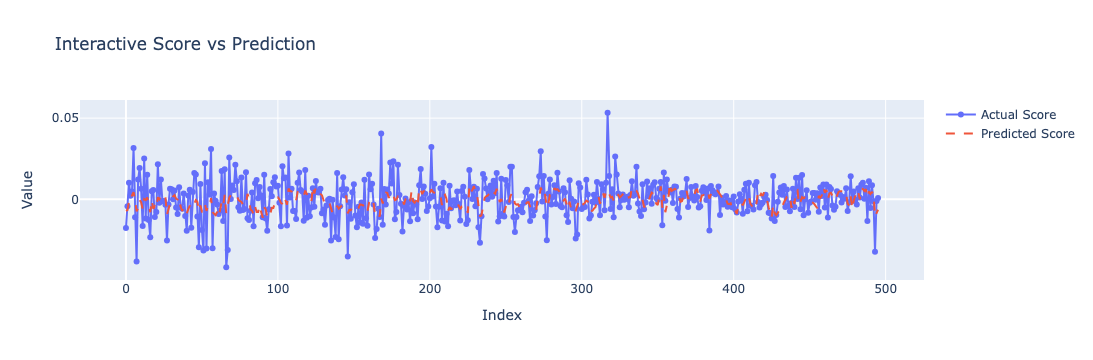

In [463]:
import plotly.graph_objects as go

fig = go.Figure()

# Add Actual Score
fig.add_trace(go.Scatter(y=test_result_df['score'], name='Actual Score', mode='lines+markers'))

# Add Predicted Score
fig.add_trace(go.Scatter(y=test_result_df['pred'], name='Predicted Score', mode='lines', line=dict(dash='dash')))

fig.update_layout(
    title='Interactive Score vs Prediction',
    xaxis_title='Index',
    yaxis_title='Value',
    hovermode='x unified' # Shows both values when you hover
)

fig.show()